# 📚 [LAB-10] 11. 이원분산분석 (Twoway ANOVA) (2)

In [1]:
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt

# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene

# 분산분석을 위한 라이브러리
from pingouin import anova
from pingouin import welch_anova

# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)  # 폰트의 속성을 읽어옴
fname = fprop.get_name()  # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams["font.family"] = fname
plt.rcParams["font.size"] = 10
plt.rcParams["axes.unicode_minus"] = False

In [3]:
origin = load_data("head_size")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/head_size.xlsx
[desc] 3명의 태아를 대상으로 3명의 관측자가 측정한 태아의 머리 둘레 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (60, 4)
열 개수: 4
행 개수: 60

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   측정자번호   60 non-null     int64  
 1   1번태아    60 non-null     float64
 2   2번태아    60 non-null     float64
 3   3번태아    60 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.0 KB
None


,측정자번호,1번태아,2번태아,3번태아
0,1,14.9,19.7,13.0
1,1,14.4,20.7,13.5
2,1,14.4,19.9,13.2
3,1,15.1,20.2,12.8
4,1,15.4,19.4,13.8


In [4]:
df = melt(
    origin,
    id_vars="측정자번호",
    value_vars=["1번태아", "2번태아", "3번태아"],
    var_name="태아번호",
    value_name="머리둘레",
)
df.head()

,측정자번호,태아번호,머리둘레
0,1,1번태아,14.9
1,1,1번태아,14.4
2,1,1번태아,14.4
3,1,1번태아,15.1
4,1,1번태아,15.4


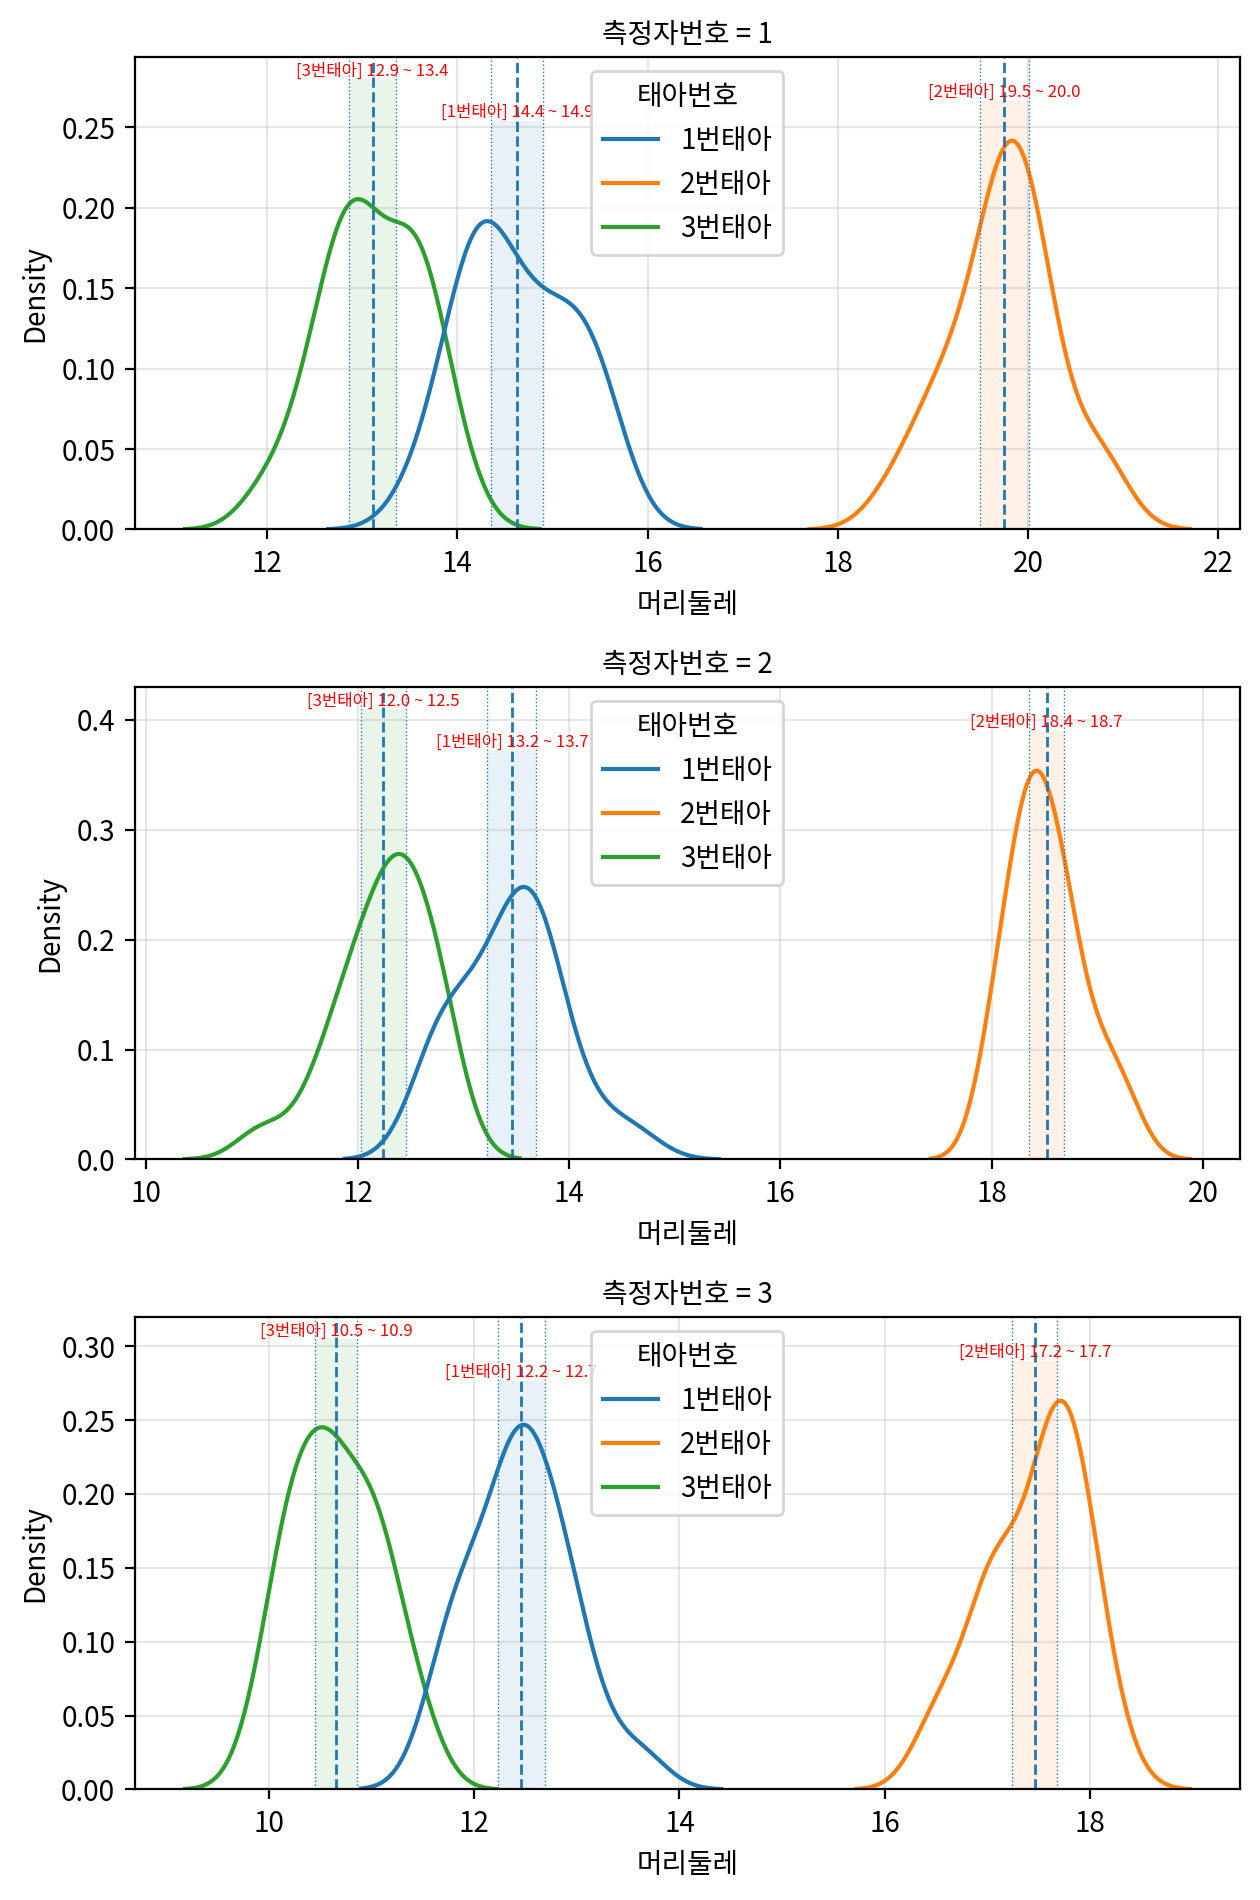

In [7]:
field = "머리둘레"
group_field = "측정자번호"
hue_field = "태아번호"

# 시각화 할 필드만 원본 데이터에서 추출
data = df[[field, group_field, hue_field]]
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# rows가 1이면 ax가 단일 객체이므로 리스트로 변환
axes = ax if rows > 1 else [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=axes[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        # 신뢰구간 계산
        max_val = temp_sub[field].max()  # 최대값 (필요시 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        axes[i].axvline(cmin, linestyle=":", linewidth=0.5)
        axes[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = axes[i].get_ylim()
        axes[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        axes[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        axes[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

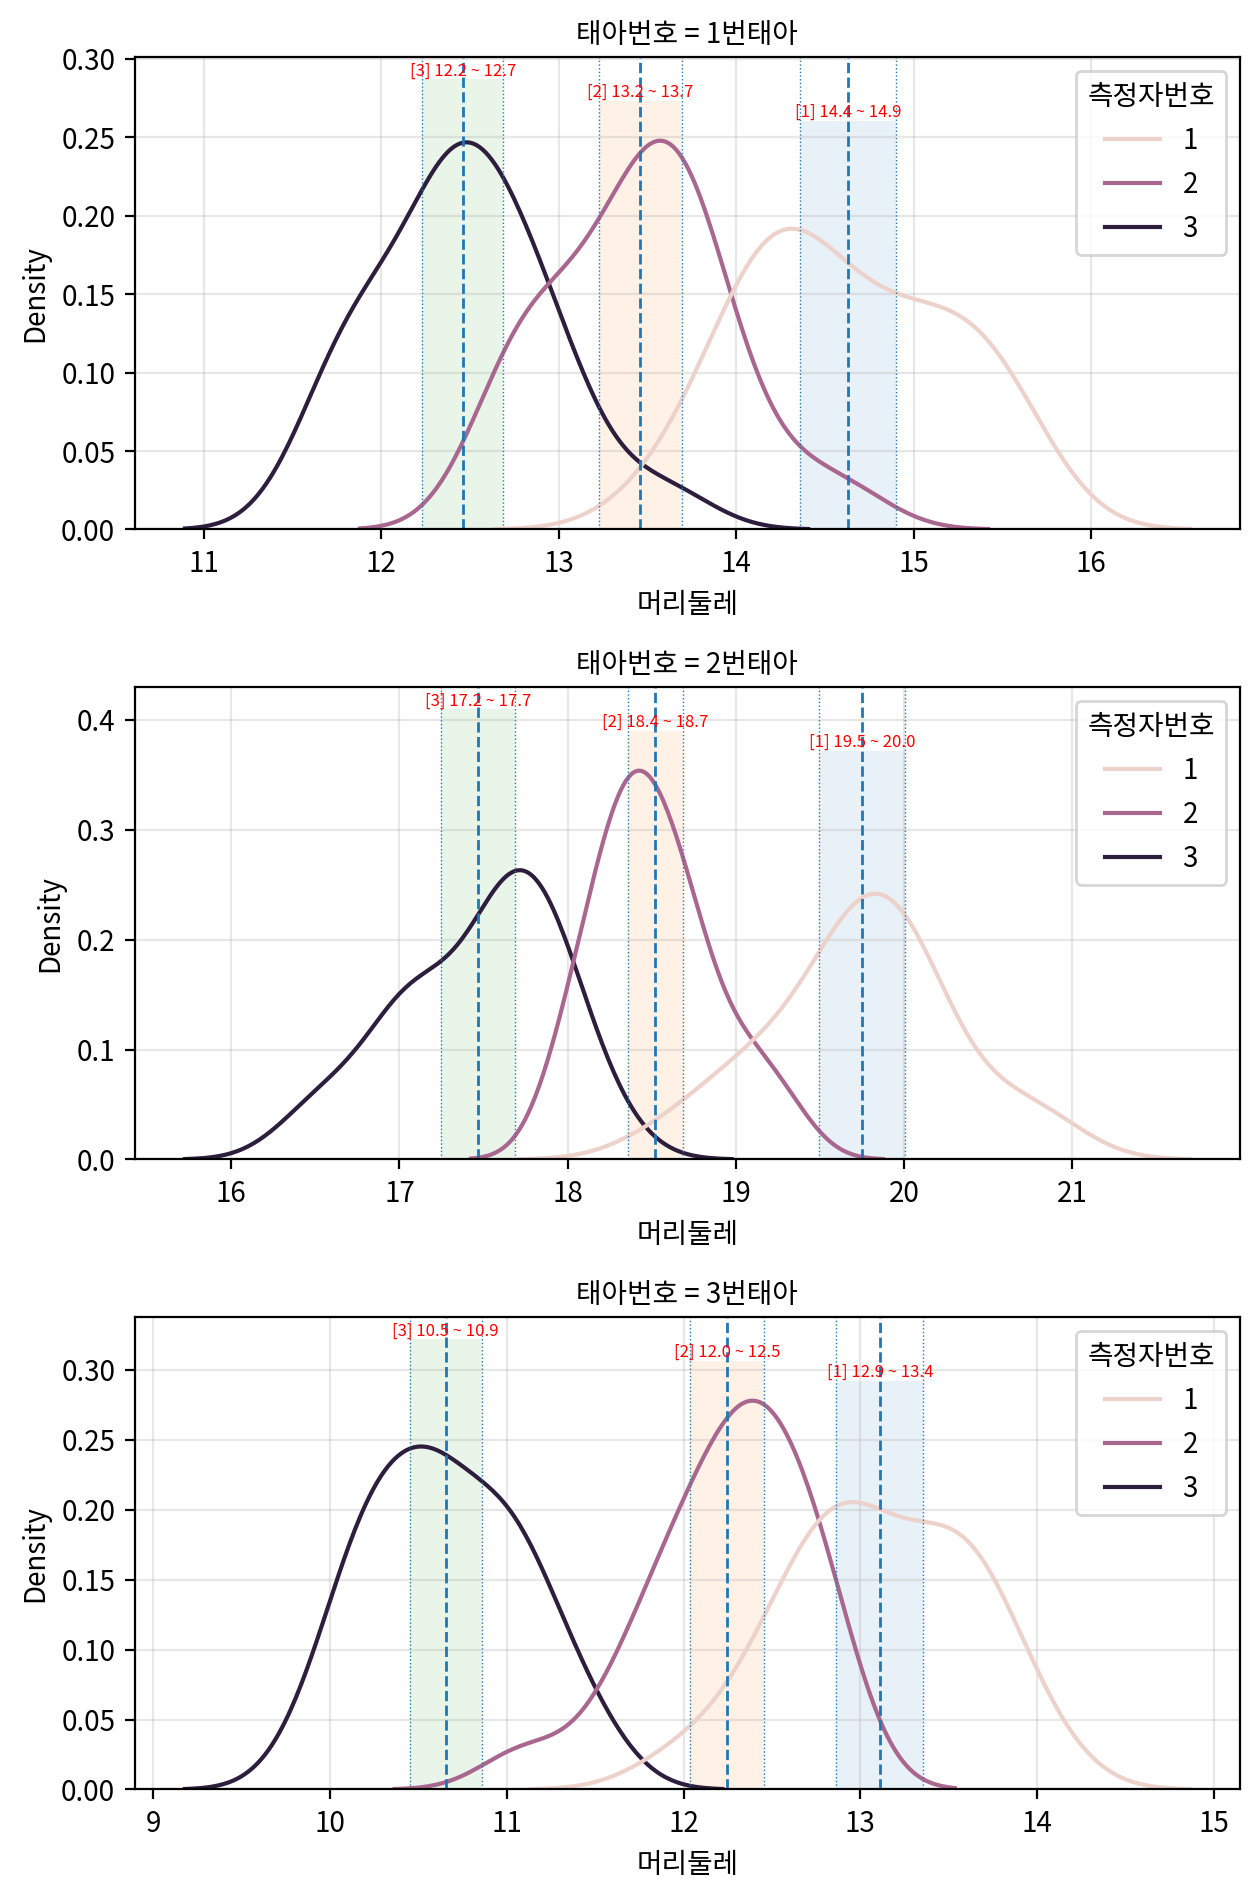

In [8]:
field = "머리둘레"
group_field = "태아번호"
hue_field = "측정자번호"

# 시각화 할 필드만 원본 데이터에서 추출
data = df[[field, group_field, hue_field]].dropna()
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# rows가 1이면 ax가 단일 객체이므로 리스트로 변환
axes = ax if rows > 1 else [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=axes[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        # 신뢰구간 계산
        max_val = temp_sub[field].max()  # 최대값 (필요시 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        axes[i].axvline(cmin, linestyle=":", linewidth=0.5)
        axes[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = axes[i].get_ylim()
        axes[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        axes[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        axes[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [9]:
data = df.copy()
xname = ["측정자번호", "태아번호"]
yname = "머리둘레"

u1 = data[xname[0]].unique()
u2 = data[xname[1]].unique()

equal_var_fields = []
normal_dist = True
report = []

for i in u1:
    for j in u2:
        # 두 요인의 조합별로 데이터 필터링
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]] == j)][
            yname
        ].dropna()

        # 데이터가 없으면 스킵
        if len(filtered_data) == 0:
            continue

        equal_var_fields.append(filtered_data)

        # 정규성 검정
        s, p = normaltest(filtered_data)
        normalize = p > 0.05

        report.append(
            {
                "field": "{0}={1}, {2}={3}".format(xname[0], i, xname[1], j),
                "statistic": s,
                "p-value": p,
                "result": normalize,
            }
        )

        normal_dist = normal_dist and normalize

# 전체 그룹들이 모두 정규성을 만족하는지에 따라 등분산 검정 선택
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)

equal_var = p > 0.05  # 필요하면 따로 사용

report.append({"field": n, "statistic": s, "p-value": p, "result": p > 0.05})

report_df = DataFrame(report).set_index("field")
report_df

,statistic,p-value,result
field,,,
"측정자번호=1, 태아번호=1번태아",1.885153,0.389623,True
"측정자번호=1, 태아번호=2번태아",0.290183,0.864943,True
"측정자번호=1, 태아번호=3번태아",0.408716,0.815171,True
"측정자번호=2, 태아번호=1번태아",0.454973,0.796533,True
"측정자번호=2, 태아번호=2번태아",1.442948,0.486035,True
"측정자번호=2, 태아번호=3번태아",3.862339,0.144979,True
"측정자번호=3, 태아번호=1번태아",0.666927,0.716438,True
"측정자번호=3, 태아번호=2번태아",1.463170,0.481146,True
"측정자번호=3, 태아번호=3번태아",0.846989,0.654755,True


In [10]:
xname = ["측정자번호", "태아번호"]
yname = "머리둘레"
data = df[xname + [yname]]

if equal_var:
    pg_anova = anova(data=data, dv=yname, between=xname)
else:
    pg_anova = welch_anova(data=data, dv=yname, between=xname)

display(pg_anova)

for idx in pg_anova.index:
    row = pg_anova.iloc[idx]
    source = row["Source"]
    p_val = row["p-unc"]

    if p_val <= 0.05:
        print(f"→ {source} 효과는 유의함. (대립가설 채택: p ≤ 0.05)")
    else:
        print(f"→ {source} 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)")

,Source,SS,DF,MS,F,p-unc,np2
0,측정자번호,159.320778,2,79.660389,336.822068,4.904107e-60,0.797548
1,태아번호,1422.825444,2,711.412722,3008.013241,5.616407e-134,0.972362
2,측정자번호 * 태아번호,2.201222,4,0.550306,2.326816,5.827850e-02,0.051619
3,Residual,40.442500,171,0.236506,NaN,NaN,NaN


→ 측정자번호 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ 태아번호 효과는 유의함. (대립가설 채택: p ≤ 0.05)
→ 측정자번호 * 태아번호 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)
→ Residual 효과는 유의하지 않음. (귀무가설 채택: p > 0.05)


In [12]:
xname = ["측정자번호", "태아번호"]
yname = "머리둘레"

data = df[xname + [yname]]

levels = {}  # 빈 딕셔너리 만들기
# 예: {'water': 2, 'sun': 3} 이런 식 결과
for factor in xname:  # 요인을 하나씩 꺼냄
    level_count = data[factor].nunique()  # 요인의 수준 수 계산
    levels[factor] = level_count  # 딕셔너리에 저장

pvals = {}  # 빈 딕셔너리 만들기
# 예: {'water': 1.30e-20, 'sun': 2.01e-17, 'water * sun': 0.105}
for index, row in pg_anova.iterrows():  # 행을 하나씩 꺼냄
    source_name = row["Source"]  # 요인 이름
    p_value = row["p-unc"]  # 각 요인의 p-value
    pvals[source_name] = p_value  # 딕셔너리에 저장

# 주효과 사후검정
for factor in xname:
    print(f"\n[{factor}]")

    # 수준이 2개면 사후검정 필요 없음
    if levels[factor] == 2:
        print(f"- {levels[factor]}수준 요인이므로 사후검정이 필요 없습니다.")
        continue

    p_val = pvals.get(factor, None)
    if p_val is None:
        print("- ANOVA 결과에서 해당 요인을 찾을 수 없습니다.")
        continue

    if p_val > 0.05:
        print(f"- 주효과 유의하지 않음 (p={p_val:.3g}) → 사후검정 수행 안 함")
        continue

    print(f"- 주효과 유의 (p={p_val:.3g}) → 사후검정 수행")

    if equal_var:
        print(" · Tukey HSD 사용 (등분산 충족)")
        hoc_df = pairwise_tukey(data=data, dv=yname, between=factor)
    else:
        print(" · Games–Howell 사용 (등분산 불충족)")
        hoc_df = pairwise_gameshowell(data=data, dv=yname, between=factor)

    display(hoc_df)

# 상호작용 자동 처리
interaction_names = [src for src in pvals.keys() if "*" in src]

for inter in interaction_names:
    p_val = pvals[inter]
    print(f"\n[{inter}] 상호작용 효과")

    if p_val <= 0.05:
        print(f"- 상호작용 유의 (p={p_val:.3g}) → 단순주효과 분석 필요")
    else:
        print(f"- 상호작용 유의하지 않음 (p={p_val:.3g}) → 단순주효과 분석 필요 없음")


[측정자번호]
- 주효과 유의 (p=4.9e-60) → 사후검정 수행
 · Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,1,2,15.830000,14.741667,1.088333,0.525341,2.071671,0.098702,0.380087
1,1,3,15.830000,13.526667,2.303333,0.525341,4.384456,0.000059,0.781644
2,2,3,14.741667,13.526667,1.215000,0.525341,2.312785,0.056613,0.422358



[태아번호]
- 주효과 유의 (p=5.62e-134) → 사후검정 수행
 · Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,1번태아,2번태아,13.516667,18.578333,-5.061667,0.195025,-25.953939,1.743050e-14,-4.841750
1,1번태아,3번태아,13.516667,12.003333,1.513333,0.195025,7.759689,1.972755e-12,1.393082
2,2번태아,3번태아,18.578333,12.003333,6.575000,0.195025,33.713629,1.743050e-14,6.016793



[측정자번호 * 태아번호] 상호작용 효과
- 상호작용 유의하지 않음 (p=0.0583) → 단순주효과 분석 필요 없음
